In [4]:
import pandas as pd

In [5]:
resume_df = pd.read_csv("../data/Resume.csv")
job_df = pd.read_csv("../data/monster_com-job_sample.csv")
resume_df.sample(10)

,ID,Resume_str,Resume_html,Category
1403,28092317,EXECUTIVE CHEF Summary Motiv...,"<div class=""fontsize fontface vmargins hmargin...",CHEF
997,23760084,SALES Summary General Sales...,"<div class=""fontsize fontface vmargins hmargin...",SALES
1324,91515108,POLICY SERVICE SPECIALIST III ...,"<div class=""fontsize fontface vmargins hmargin...",AUTOMOBILE
1717,50328713,ENGINEERING INTERN Skills ...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING
1519,24411323,FINANCE MANAGER Summary Top\...,"<div class=""fontsize fontface vmargins hmargin...",FINANCE
527,27182111,REGISTERED NURSE CLINICAL CARE COORDI...,"<div class=""fontsize fontface vmargins hmargin...",ADVOCATE
147,10748989,LIGHTING DESIGNER Professional ...,"<div class=""fontsize fontface vmargins hmargin...",DESIGNER
1634,29640922,COLOUR ANALYST Summary Creat...,"<div class=""fontsize fontface vmargins hmargin...",APPAREL
525,24124250,SENIOR APPLICATION SPECIALIST P...,"<div class=""fontsize fontface vmargins hmargin...",ADVOCATE
1797,86209934,SENIOR MANUFACTURING ENGINEERING ...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING


In [6]:
resume_df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='str')

In [7]:
job_df.columns

Index(['country', 'country_code', 'date_added', 'has_expired', 'job_board',
       'job_description', 'job_title', 'job_type', 'location', 'organization',
       'page_url', 'salary', 'sector', 'uniq_id'],
      dtype='str')

In [8]:
resume_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           2484 non-null   int64
 1   Resume_str   2484 non-null   str  
 2   Resume_html  2484 non-null   str  
 3   Category     2484 non-null   str  
dtypes: int64(1), str(3)
memory usage: 77.8 KB


In [9]:
resume_df.isna().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

In [10]:
job_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   country          22000 non-null  str  
 1   country_code     22000 non-null  str  
 2   date_added       122 non-null    str  
 3   has_expired      22000 non-null  str  
 4   job_board        22000 non-null  str  
 5   job_description  22000 non-null  str  
 6   job_title        22000 non-null  str  
 7   job_type         20372 non-null  str  
 8   location         22000 non-null  str  
 9   organization     15133 non-null  str  
 10  page_url         22000 non-null  str  
 11  salary           3446 non-null   str  
 12  sector           16806 non-null  str  
 13  uniq_id          22000 non-null  str  
dtypes: str(14)
memory usage: 2.3 MB


In [11]:
job_df.isna().sum()

country                0
country_code           0
date_added         21878
has_expired            0
job_board              0
job_description        0
job_title              0
job_type            1628
location               0
organization        6867
page_url               0
salary             18554
sector              5194
uniq_id                0
dtype: int64

In [12]:
job_df.shape

(22000, 14)

In [13]:
print(resume_df['Resume_str'].iloc[0])

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss preve

In [14]:
import re

def clean_text(text):

    text = str(text)              # ensure it's string
    text = text.lower()           # lowercase
    
    text = re.sub(r'\n', ' ', text)     # remove newlines
    
    text = re.sub(r'[^a-zA-Z ]', ' ', text)   # keep only letters
    
    text = re.sub(r'\s+', ' ', text)    # remove extra spaces
    
    return text.strip()

In [15]:
resume_df['clean_resume'] = resume_df['Resume_str'].apply(clean_text)

In [16]:
resume_df[['Resume_str','clean_resume']].head()

,Resume_str,clean_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over years experience in r...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


In [17]:
resume_df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category', 'clean_resume'], dtype='str')

In [18]:
resume_df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

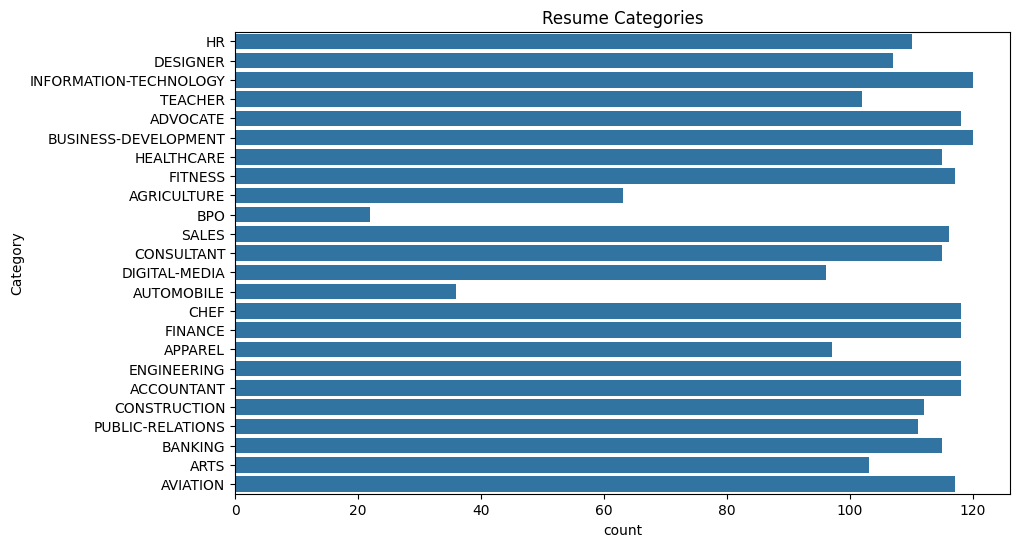

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(resume_df['Category'])
plt.title("Resume Categories")
plt.show()

In [20]:
skills_list = [
'python',
'java',
'c++',
'javascript',
'sql',
'machine learning',
'deep learning',
'data science',
'data analysis',
'pandas',
'numpy',
'scikit learn',
'tensorflow',
'pytorch',
'docker',
'kubernetes',
'aws',
'azure',
'git',
'react',
'nodejs',
'html',
'css',
'marketing',
'customer service',
'human resources',
'accounting',
'finance',
'statistics'
]

In [21]:
def extract_skills(resume_text):
    resume_text = resume_text.lower()
    found_skills = []
    
    for skill in skills_list:
        if skill in resume_text:
            found_skills.append(skill)

    return found_skills

In [22]:
sample_resume = resume_df['Resume_str'].iloc[0]
extract_skills(sample_resume)

['data analysis',
 'aws',
 'marketing',
 'customer service',
 'human resources',
 'accounting',
 'statistics']

In [23]:
resume_df['skills'] = resume_df['Resume_str'].apply(extract_skills)

In [24]:
resume_df[['Category','skills']].head(10)

,Category,skills
0,HR,"[data analysis, aws, marketing, customer servi..."
1,HR,"[git, marketing, human resources]"
2,HR,"[marketing, customer service, human resources]"
3,HR,[customer service]
4,HR,"[aws, human resources]"
5,HR,[human resources]
6,HR,"[customer service, human resources]"
7,HR,"[aws, customer service, human resources]"
8,HR,"[aws, customer service]"
9,HR,"[aws, human resources, accounting]"


In [25]:
resume_df[['Category','skills']].sample(5)

,Category,skills
709,HEALTHCARE,[marketing]
813,FITNESS,[]
2331,ARTS,"[data analysis, finance]"
1598,APPAREL,[git]
294,INFORMATION-TECHNOLOGY,"[sql, git, marketing, customer service, accoun..."


In [26]:
from collections import Counter

all_skills = []

for skill in resume_df['skills']:
    all_skills.extend(skill)

Counter(all_skills).most_common(10)


[('customer service', 990),
 ('marketing', 875),
 ('accounting', 560),
 ('finance', 477),
 ('git', 330),
 ('aws', 302),
 ('human resources', 283),
 ('sql', 191),
 ('html', 158),
 ('statistics', 139)]

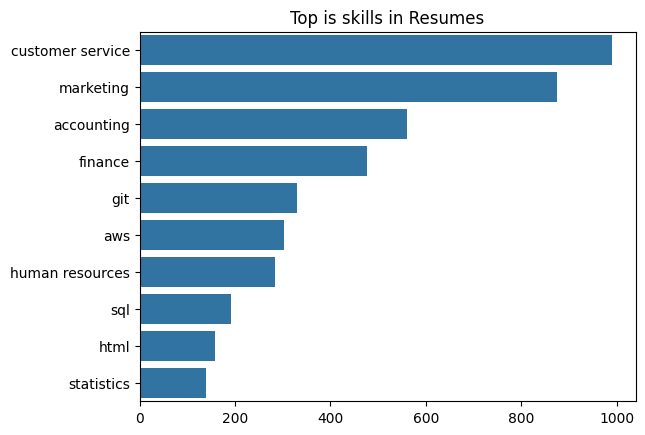

In [27]:
skills_count = Counter(all_skills)

top_skills = dict(skills_count.most_common(10))

sns.barplot(x=list(top_skills.values()),y=list(top_skills.keys()))
plt.title("Top is skills in Resumes")
plt.show()

In [28]:
resume_df.to_csv("../data/resumes_with_skills.csv", index=False)

In [29]:
job_descriptions = {
    
"Data Scientist": """
Looking for a Data Scientist with experience in Python, machine learning,
data analysis, statistics, pandas, numpy and SQL.
""",

"Web Developer": """
Looking for a Web Developer skilled in HTML, CSS, JavaScript, React,
NodeJS and Git.
""",

"HR Manager": """
Looking for an HR professional with experience in human resources,
employee relations, recruitment, payroll and customer service.
"""
}

In [30]:
for job, desc in job_descriptions.items():
    
    print(job)
    
    print(extract_skills(desc))
    
    print()

Data Scientist
['python', 'sql', 'machine learning', 'data analysis', 'pandas', 'numpy', 'statistics']

Web Developer
['java', 'javascript', 'git', 'react', 'nodejs', 'html', 'css']

HR Manager
['customer service', 'human resources']



Building the AI Engine

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

Converting Resuming and Job text into Vectors

In [32]:
# resume_text = resume_df['clean_resume'].iloc[0]
# job_text = clean_text(job_descriptions["Data Scientist"])

In [33]:
# documents = [resume_text, job_text]

In [34]:
# vectorizer = TfidfVectorizer()
# tfidf_matrix = vectorizer.fit_transform(documents)

Calculating Similarity Score

In [35]:
# similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])
# print(similarity)

Now AI can score resumes

In [36]:
# match_score = similarity[0][0]*100
# print("Match Score:",round(match_score,2),"%")

Calculating Missing Skills

In [37]:
# resume_skills = extract_skills(resume_text)
# job_skills = extract_skills(job_text)

Creating a Clean Function 

In [38]:
# def analyze_resume(resume_text, job_text):

#     resume_text = clean_text(resume_text)
#     job_text = clean_text(job_text)

#     resume_skills = extract_skills(resume_text)
    
#     job_skills = extract_skills(job_text)
    
#     documents = [resume_text, job_text]
    
#     vectorizer = TfidfVectorizer()
    
#     tfidf_matrix = vectorizer.fit_transform(documents)
    
#     similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])
    
#     match_score = similarity[0][0] * 100
    
#     missing_skills = list(set(job_skills) - set(resume_skills))
    
#     return match_score, resume_skills, missing_skills

In [39]:
# for i in range(5):

#     resume = resume_df['clean_resume'].iloc[i]
    
#     score, skills, missing = analyze_resume(resume, job_descriptions["HR Manager"])
    
#     print("Resume",i)
    
#     print("Score:",score)
    
#     print("Missing:",missing)
    
#     print()

In [40]:
import sys
sys.path.append("../src")

from skill_extraction import extract_skills

In [41]:
#test for the skill_extractor

# text = "I have experience in python ,SQL and machine learning"
# skills = extract_skills(text)
# print(skills)

In [42]:
import importlib
import skill_extraction

importlib.reload(skill_extraction)

<module 'skill_extraction' from 'd:\\AI-Resume-Analyzer\\notebook\\../src\\skill_extraction.py'>

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def analyze_resume(resume_text, job_text):

    # Extract skills using your module
    resume_skills = extract_skills(resume_text)
    job_skills = extract_skills(job_text)

    print("Resume Skills:", resume_skills)
    print("Job Skills:", job_skills)

    # Convert list → text
    resume_skill_text = " ".join(resume_skills)
    job_skill_text = " ".join(job_skills)

    # TF-IDF
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform([resume_skill_text, job_skill_text])

    # Similarity
    similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])

    score = similarity[0][0] * 100

    # Missing skills
    missing = list(set(job_skills) - set(resume_skills))

    return score, resume_skills, missing

In [44]:
for i in range(5):

    resume = resume_df['clean_resume'].iloc[i]
    
    score, skills, missing = analyze_resume(
        resume,
        job_descriptions["Data Scientist"]
    )
    
    print("Resume", i)
    print("Score:", score)
    print("Skills:", skills)
    print("Missing:", missing)
    print()

Resume Skills: ['management', 'data analysis', 'marketing']
Job Skills: ['machine learning', 'python', 'sql', 'data analysis']
Resume 0
Score: 26.055567105626242
Skills: ['management', 'data analysis', 'marketing']
Missing: ['machine learning', 'python', 'sql']

Resume Skills: ['management', 'marketing', 'communication']
Job Skills: ['machine learning', 'python', 'sql', 'data analysis']
Resume 1
Score: 0.0
Skills: ['management', 'marketing', 'communication']
Missing: ['machine learning', 'python', 'sql', 'data analysis']

Resume Skills: ['management', 'excel', 'marketing']
Job Skills: ['machine learning', 'python', 'sql', 'data analysis']
Resume 2
Score: 0.0
Skills: ['management', 'excel', 'marketing']
Missing: ['machine learning', 'python', 'sql', 'data analysis']

Resume Skills: ['management', 'excel', 'communication']
Job Skills: ['machine learning', 'python', 'sql', 'data analysis']
Resume 3
Score: 0.0
Skills: ['management', 'excel', 'communication']
Missing: ['machine learning', '

In [48]:
import sys
sys.path.append("../src")

from matcher import analyze_resume, rank_resumes

In [50]:
import sys
sys.path.append("../src")

from skill_extraction import extract_skills

In [ ]:
ranked_results = rank_resumes(
    resume_df,
    job_descriptions["Data Scientist"]
)

for i, res in enumerate(ranked_results[:5]):  # returns top 5 resumes
    print(f"Rank {i+1}")
    print("Resume Index:", res["index"])
    print("Score:", res["score"])
    print()

Rank 1
Resume Index: 1348
Score: 96.02091054882787

Rank 2
Resume Index: 2153
Score: 96.02091054882787

Rank 3
Resume Index: 1218
Score: 93.29543591423547

Rank 4
Resume Index: 1762
Score: 93.29543591423547

Rank 5
Resume Index: 1717
Score: 73.7789179981882

